<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/03_classical_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "your-actual-github-email@example.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 48 (delta 20), reused 22 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 1.15 MiB | 1.55 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — imports + config for Fig.3's condition
import numpy as np
from sklearn.metrics import roc_auc_score
from src.channel import SignalConfig, mix_signal, generate_soi, generate_noise
from src.model import estimate_covariance, mahalanobis_score, fit_pca_detector, pca_score

# OUR ASSUMPTION: fd_max=0.0 reproduces Fig.3's "no Frequency Shift" condition
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)

N_SYMBOLS = 16   # OUR ASSUMPTION: detection window length (not specified in paper)
SIR_DB = 20.0    # BASE-PAPER FACT (Fig.3 caption)
SNR_DB = 15.0    # BASE-PAPER FACT (Fig.3 caption)

In [3]:
# Cell 3 — build interference-free training pool, fit C and PCA
def make_clean_sample(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    return s + w / np.sqrt(rho_snr)

M_TRAIN = 2000  # sized so covariance dim (2*16*8=256) is well-estimated
clean_samples = [make_clean_sample(cfg, N_SYMBOLS, SNR_DB, rng) for _ in range(M_TRAIN)]

C = estimate_covariance(clean_samples)
C_inv = np.linalg.inv(C)
pca = fit_pca_detector(clean_samples)
print("Covariance shape:", C.shape, " | PCA components kept:", pca.n_components_)

Covariance shape: (256, 256)  | PCA components kept: 31


In [4]:
# Cell 4 — build labeled test sets and score both detectors
def build_test_set(cfg, n_symbols, rng, interference_type, n_test, sir_db, snr_db):
    samples, labels = [], []
    for _ in range(n_test):
        d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                        contamination=0.5,  # BASE-PAPER FACT: test contamination = 50%
                        sir_db_range=(sir_db, sir_db), snr_db_range=(snr_db, snr_db),
                        apply_shift=False)
        samples.append(d["x"]); labels.append(d["label"])
    return samples, np.array(labels, dtype=int)

results = {}
# OUR ASSUMPTION: "AWGN" in Fig.3/Table1 = our "fawgn" (Filtered AWGN)
for itype in ["tone", "chirp", "fawgn"]:
    samples, labels = build_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
    maha_scores = [mahalanobis_score(x, C_inv) for x in samples]
    pca_scores  = [pca_score(x, pca) for x in samples]
    results[itype] = {
        "mahalanobis": roc_auc_score(labels, maha_scores),
        "pca": roc_auc_score(labels, pca_scores),
    }
    print(f"{itype:6s}  Mahalanobis AUC={results[itype]['mahalanobis']:.4f}  "
          f"PCA AUC={results[itype]['pca']:.4f}")

tone    Mahalanobis AUC=0.8813  PCA AUC=0.6267
chirp   Mahalanobis AUC=0.8131  PCA AUC=0.6606
fawgn   Mahalanobis AUC=0.8925  PCA AUC=0.7091


       paper_mahalanobis_auc  our_mahalanobis_auc  difference
tone                  0.9861             0.881318   -0.104782
chirp                 0.9955             0.813116   -0.182384
fawgn                 0.9954             0.892457   -0.102943


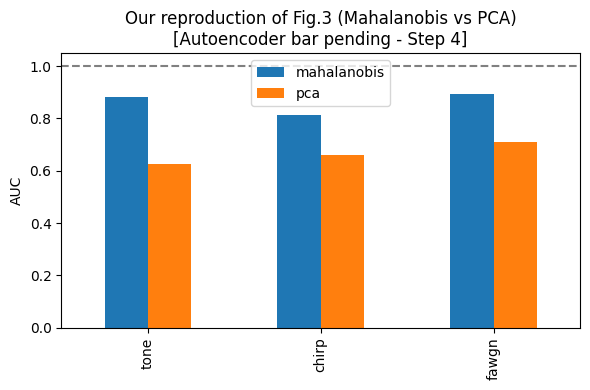

In [5]:
# Cell 5 — reproducibility comparison vs paper's Table 1 (Modulation:No, Random Shift:No row)
import pandas as pd
import matplotlib.pyplot as plt

paper_mahalanobis = {"tone": 0.9861, "chirp": 0.9955, "fawgn": 0.9954}  # BASE-PAPER FACT

df = pd.DataFrame(results).T
comparison = pd.DataFrame({
    "paper_mahalanobis_auc": paper_mahalanobis,
    "our_mahalanobis_auc": df["mahalanobis"],
})
comparison["difference"] = comparison["our_mahalanobis_auc"] - comparison["paper_mahalanobis_auc"]
print(comparison)

df.plot(kind="bar", figsize=(6,4))
plt.ylabel("AUC"); plt.axhline(1.0, linestyle="--", color="gray")
plt.title("Our reproduction of Fig.3 (Mahalanobis vs PCA)\n[Autoencoder bar pending - Step 4]")
plt.tight_layout()
plt.savefig("figures/fig3_reproduction_partial.png", dpi=150)
plt.show()

os.makedirs("results", exist_ok=True)
comparison.to_csv("results/mahalanobis_reproducibility_table.csv")
df.to_csv("results/fig3_partial_auc.csv")

{'n_symbols': 16, 'dim': 256, 'm_train': 3840, 'tone_auc': np.float64(0.8128320802005011), 'chirp_auc': np.float64(0.8534271725826194), 'fawgn_auc': np.float64(0.9437443290654299)}
{'n_symbols': 32, 'dim': 512, 'm_train': 7680, 'tone_auc': np.float64(0.88), 'chirp_auc': np.float64(0.8983826670735429), 'fawgn_auc': np.float64(0.9864335242689176)}
{'n_symbols': 64, 'dim': 1024, 'm_train': 15360, 'tone_auc': np.float64(0.8740985576923077), 'chirp_auc': np.float64(0.9235752606539124), 'fawgn_auc': np.float64(0.9984903381642513)}
{'n_symbols': 128, 'dim': 2048, 'm_train': 30720, 'tone_auc': np.float64(0.8713368125250903), 'chirp_auc': np.float64(0.9468643805993203), 'fawgn_auc': np.float64(1.0)}


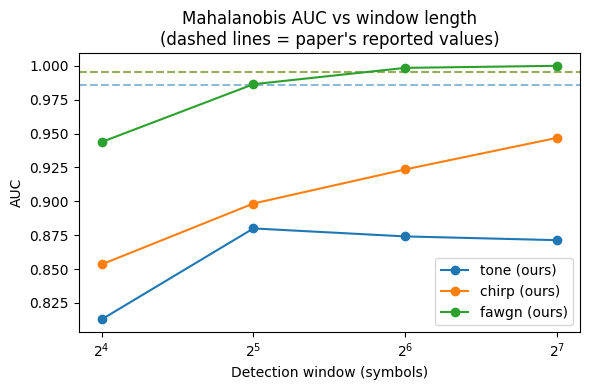

In [6]:
# Cell 6 — diagnostic: is our unstated window-length assumption driving the AUC gap?
window_lengths = [16, 32, 64, 128]  # symbols
sweep_results = []

for n_sym in window_lengths:
    dim = 2 * n_sym * cfg.NSPS
    m_train = max(2000, 15 * dim)  # keep sample:dimension ratio healthy as dim grows

    clean = [make_clean_sample(cfg, n_sym, SNR_DB, rng) for _ in range(m_train)]
    C_sweep = estimate_covariance(clean)
    Cinv_sweep = np.linalg.inv(C_sweep)

    row = {"n_symbols": n_sym, "dim": dim, "m_train": m_train}
    for itype in ["tone", "chirp", "fawgn"]:
        samples, labels = build_test_set(cfg, n_sym, rng, itype, 200, SIR_DB, SNR_DB)
        scores = [mahalanobis_score(x, Cinv_sweep) for x in samples]
        row[f"{itype}_auc"] = roc_auc_score(labels, scores)
    sweep_results.append(row)
    print(row)

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv("results/window_length_sweep.csv", index=False)

plt.figure(figsize=(6,4))
colors = {"tone": "tab:blue", "chirp": "tab:orange", "fawgn": "tab:green"}
for itype, paper_val in paper_mahalanobis.items():
    plt.plot(sweep_df["n_symbols"], sweep_df[f"{itype}_auc"], marker='o',
              label=f"{itype} (ours)", color=colors[itype])
    plt.axhline(paper_val, linestyle='--', alpha=0.5, color=colors[itype])
plt.xscale('log', base=2)
plt.xlabel("Detection window (symbols)"); plt.ylabel("AUC")
plt.title("Mahalanobis AUC vs window length\n(dashed lines = paper's reported values)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/window_length_sweep.png", dpi=150)
plt.show()

fz= -8000.0 Hz  AUC=1.0000
fz= -6000.0 Hz  AUC=1.0000
fz= -4000.0 Hz  AUC=0.9958
fz= -2000.0 Hz  AUC=0.8043
fz=     0.0 Hz  AUC=0.4862
fz=  2000.0 Hz  AUC=0.8453
fz=  4000.0 Hz  AUC=0.9995
fz=  6000.0 Hz  AUC=1.0000
fz=  8000.0 Hz  AUC=1.0000


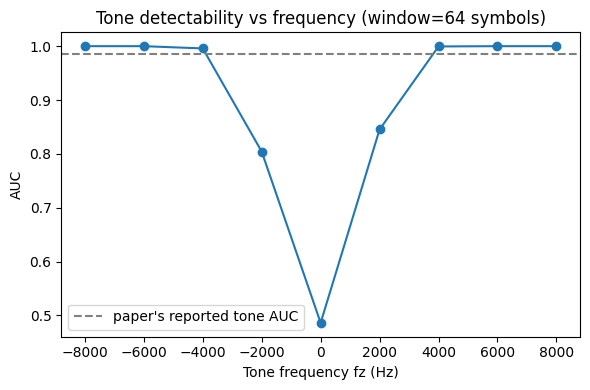

In [7]:
# Cell 7 — does tone detectability depend on the tone's own frequency?
N_DIAG = 64
dim_diag = 2 * N_DIAG * cfg.NSPS
m_diag = 15 * dim_diag

clean_diag = [make_clean_sample(cfg, N_DIAG, SNR_DB, rng) for _ in range(m_diag)]
C_diag = estimate_covariance(clean_diag)
Cinv_diag = np.linalg.inv(C_diag)

def make_tone_sample_at_freq(cfg, n_symbols, snr_db, sir_db, fz, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    n = np.arange(len(s))
    phi_z = rng.uniform(0, 2*np.pi)
    z = np.exp(1j*(2*np.pi*fz/cfg.Fs*n + phi_z))
    w = generate_noise(len(s), rng)
    rho_sir, rho_snr = 10**(sir_db/10), 10**(snr_db/10)
    return s + z/np.sqrt(rho_sir) + w/np.sqrt(rho_snr)

freq_grid = np.linspace(-cfg.Rs, cfg.Rs, 9)
n_per_freq = 100
freq_results = []

for fz in freq_grid:
    pos = [make_tone_sample_at_freq(cfg, N_DIAG, SNR_DB, SIR_DB, fz, rng) for _ in range(n_per_freq)]
    neg = [make_clean_sample(cfg, N_DIAG, SNR_DB, rng) for _ in range(n_per_freq)]
    scores = [mahalanobis_score(x, Cinv_diag) for x in pos + neg]
    labels_fz = np.array([1]*n_per_freq + [0]*n_per_freq)
    auc_fz = roc_auc_score(labels_fz, scores)
    freq_results.append({"fz": fz, "auc": auc_fz})
    print(f"fz={fz:8.1f} Hz  AUC={auc_fz:.4f}")

freq_df = pd.DataFrame(freq_results)
freq_df.to_csv("results/tone_freq_vs_auc.csv", index=False)

plt.figure(figsize=(6,4))
plt.plot(freq_df["fz"], freq_df["auc"], marker='o')
plt.axhline(paper_mahalanobis["tone"], linestyle='--', color='gray', label="paper's reported tone AUC")
plt.xlabel("Tone frequency fz (Hz)"); plt.ylabel("AUC")
plt.title(f"Tone detectability vs frequency (window={N_DIAG} symbols)")
plt.legend(); plt.tight_layout()
plt.savefig("figures/tone_freq_diagnostic.png", dpi=150)
plt.show()

In [8]:
!git add results/tone_freq_vs_auc.csv figures/tone_freq_diagnostic.png notebooks/03_classical_baselines.ipynb
!git commit -m "Step 3 diagnostic: confirmed frequency-dependent Mahalanobis blind spot near fz=0"
!git push

[main 5766bd7] Step 3 diagnostic: confirmed frequency-dependent Mahalanobis blind spot near fz=0
 2 files changed, 10 insertions(+)
 create mode 100644 figures/tone_freq_diagnostic.png
 create mode 100644 results/tone_freq_vs_auc.csv
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 45.95 KiB | 15.32 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   dd1505c..5766bd7  main -> main
